# Models' Performances analysis 
Here we analyse aggregated models'performances 

In [15]:
import pandas as pd

In [16]:
df = pd.read_csv("./classifiers_performances.csv")

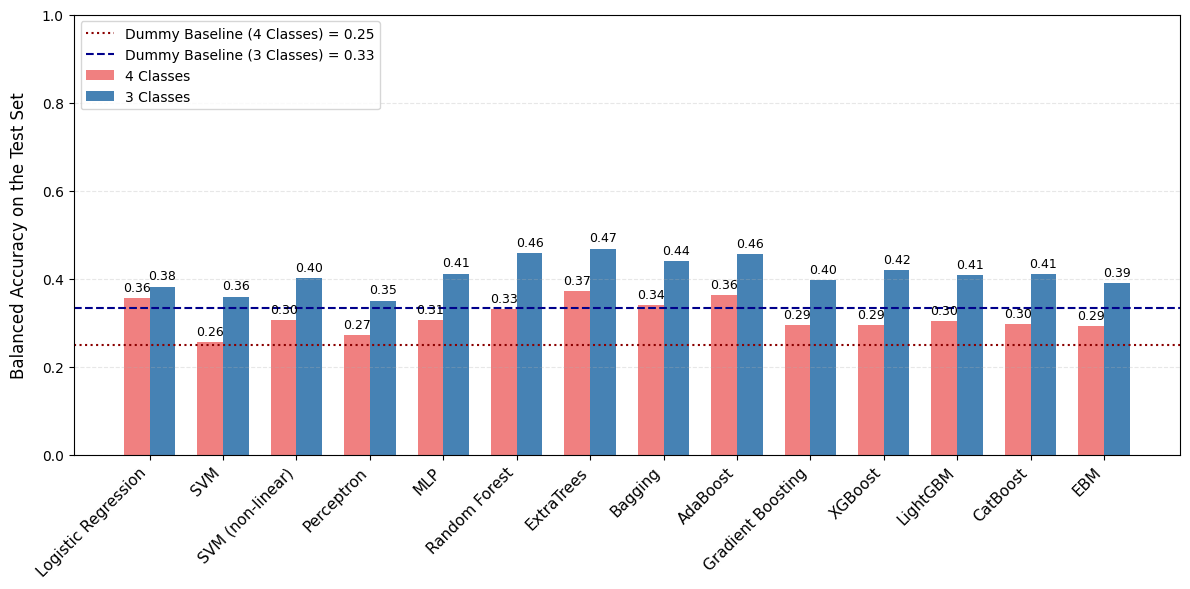

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Nomi dei classificatori testati
models = df['classifier'].tolist()

# Punteggi fittizi (sostituisci con i tuoi reali)
best_score_4classes = df['balanced_accuracy_4c'].tolist() 
best_score_3classes = df['balanced_accuracy_3c'].tolist()

x = np.arange(len(models))  
width = 0.35                 

plt.figure(figsize=(12, 6))

rects1 = plt.bar(x - width/2, best_score_4classes, width, label='4 Classes', color='lightcoral')
rects2 = plt.bar(x + width/2, best_score_3classes, width, label='3 Classes', color='steelblue')

# =========================================================================
# AGGIUNTA DELLE LINEE DI BASELINE DEL DUMMY CLASSIFIER
# =========================================================================
# Linea per il caso a 4 classi (0.25)
plt.axhline(y=0.25, color='darkred', linestyle=':', linewidth=1.5, 
            label='Dummy Baseline (4 Classes) = 0.25')

# Linea per il caso a 3 classi (0.33)
plt.axhline(y=0.333, color='darkblue', linestyle='--', linewidth=1.5, 
            label='Dummy Baseline (3 Classes) = 0.33')

# Personalizzazioni estetiche
plt.ylabel('Balanced Accuracy on the Test Set', fontsize=12, labelpad=10)
# plt.title('Model Performance Comparison w.r.t. Dummy Classifiers', fontsize=14, pad=20, fontweight='bold')
plt.xticks(x, models, fontsize=11, rotation=45, ha='right')
plt.ylim(0, 1.0) 
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Spostiamo la legenda fuori o in un punto strategico per non coprire le barre
plt.legend(fontsize=10, loc='upper left')

# Annotazione numerica sopra le barre
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [18]:
# =========================================================================
# 1. INSERIMENTO DEI DATI REALI (Sostituisci con i tuoi best_score_)
# =========================================================================
modelli = models  # Usa i nomi dei modelli dal DataFrame


# Creiamo il DataFrame iniziale
df_perf = pd.DataFrame({
    'Modello': modelli,
    'Perf_4_Classi': best_score_4classes,
    'Perf_3_Classi': best_score_3classes
})

# =========================================================================
# 2. CALCOLO DEI DELTA RISPETTO ALLE RISPETTIVE DUMMY BASELINE
# =========================================================================
baseline_4c = 0.25
baseline_3c = 1.0 / 3.0  # ~0.3333

# Calcoliamo di quanto ogni modello supera il rispettivo "caso"
df_perf['Delta_4_Classi'] = df_perf['Perf_4_Classi'] - baseline_4c
df_perf['Delta_3_Classi'] = df_perf['Perf_3_Classi'] - baseline_3c

# =========================================================================
# 3. ANALISI STATISTICA AGGREGATA
# =========================================================================
media_delta_4c = df_perf['Delta_4_Classi'].mean()
media_delta_3c = df_perf['Delta_3_Classi'].mean()

print("=== COEFFICIENTI DI DISTANZA DALLA BASELINE CASUALE ===")
print(f"Distanza media dalla baseline nel caso a 4 Classi: {media_delta_4c:.4f}")
print(f"Distanza media dalla baseline nel caso a 3 Classi: {media_delta_3c:.4f}")
print("-" * 55)

# =========================================================================
# 4. VERDETTO AUTOMATICO DA CITARE IN TESI
# =========================================================================
if media_delta_3c > media_delta_4c:
    miglioramento = (media_delta_3c - media_delta_4c) * 100
    print(f"VERDETTO: Lo scenario a 3 CLASSI è statisticamente superiore.")
    print(f"In media, i modelli a 3 classi si staccano dalla baseline casuale del {miglioramento:.2f}% IN PIÙ rispetto a quelli a 4 classi.")
    print("Questo dimostra che l'accorpamento ha rimosso rumore e fatto emergere pattern predittivi reali.")
else:
    miglioramento = (media_delta_4c - media_delta_3c) * 100
    print(f"VERDETTO: Lo scenario a 4 CLASSI mantiene un vantaggio informativo complessivo.")
    print(f"I modelli a 4 classi superano la loro baseline di un ulteriore {miglioramento:.2f}% rispetto al caso a 3 classi.")

# Mostriamo la tabella analitica per i singoli modelli
print("\n=== DETTAGLIO PER SINGOLO MODELLO ===")
display(df_perf[['Modello', 'Delta_4_Classi', 'Delta_3_Classi']])

=== COEFFICIENTI DI DISTANZA DALLA BASELINE CASUALE ===
Distanza media dalla baseline nel caso a 4 Classi: 0.0625
Distanza media dalla baseline nel caso a 3 Classi: 0.0771
-------------------------------------------------------
VERDETTO: Lo scenario a 3 CLASSI è statisticamente superiore.
In media, i modelli a 3 classi si staccano dalla baseline casuale del 1.46% IN PIÙ rispetto a quelli a 4 classi.
Questo dimostra che l'accorpamento ha rimosso rumore e fatto emergere pattern predittivi reali.

=== DETTAGLIO PER SINGOLO MODELLO ===


,Modello,Delta_4_Classi,Delta_3_Classi
0,Logistic Regression,0.1058,0.048467
1,SVM,0.0058,0.025667
2,SVM (non-linear),0.0549,0.068367
3,Perceptron,0.0208,0.016467
4,MLP,0.0559,0.077867
5,Random Forest,0.0799,0.123867
6,ExtraTrees,0.1220,0.134767
7,Bagging,0.0895,0.106867
8,AdaBoost,0.1128,0.122367
9,Gradient Boosting,0.0433,0.062367
